# Model 6 sensitivity table: imputed vs raw-adjusted

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Parameters

In [9]:
wd = '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid'

countries = {
    'Argentina': 'ARG',
    'Chile': 'CHL',
    'Colombia': 'COL',
}

groupings = ['density', 'rdi']
imputed_version = 'new'  # use 'subunit0' for the conservative-imputed branch
raw_version = 'raw_adjusted_no_imputation_r2'
model = 6


# Helpers

In [10]:
def read_model_outputs(country_short, grouping, version, model_id):
    base = os.path.join(wd, 'data', 'outputs', country_short, 'mov-analysis', f'by-{grouping}')

    if version == 'new':
        tidy_file = os.path.join(base, 'data_trend_outflows_param_tidy_results_o_new.csv')
        re_file = os.path.join(base, f'data_trend_param_quad_m{model_id}o_re_new.csv')
    else:
        tidy_file = os.path.join(base, f'data_trend_outflows_param_tidy_results_o_{version}.csv')
        re_file = os.path.join(base, f'data_trend_param_quad_m{model_id}o_re_{version}.csv')

    df_tidy = pd.read_csv(tidy_file)
    df_re = pd.read_csv(re_file)
    return df_tidy, df_re


def first_or_nan(series):
    series = series.reset_index(drop=True)
    return series.loc[0] if len(series) > 0 else np.nan


def extract_model_by_category(df_tidy, df_re, country_short, grouping, data_version, model_id):
    df_model = df_tidy[df_tidy['model'] == model_id].copy().reset_index(drop=True)

    fe_intercept = first_or_nan(
        df_model[df_model['term'].str.contains('Intercept')]['estimate']
    )
    fe_time = first_or_nan(df_model[df_model['term'] == 'time']['estimate'])
    fe_time2 = first_or_nan(df_model[df_model['term'] == 'time2']['estimate'])

    re_intercept = df_re[df_re['facet'].str.contains('Intercept')].reset_index(drop=True)
    re_time = df_re[df_re['facet'] == 'time'].reset_index(drop=True)

    rows = []
    n_rows = min(len(re_intercept), len(re_time))
    for i in range(n_rows):
        category = re_intercept.loc[i, 'term']
        rows.append({
            'country': country_short,
            'grouping': grouping,
            'category': category,
            'data_version': data_version,
            'model': model_id,
            'intercept_estimate': fe_intercept + re_intercept.loc[i, 'estimate'],
            'intercept_conf_low': fe_intercept + re_intercept.loc[i, 'conf.low'],
            'intercept_conf_high': fe_intercept + re_intercept.loc[i, 'conf.high'],
            'time_estimate': fe_time + re_time.loc[i, 'estimate'],
            'time_conf_low': fe_time + re_time.loc[i, 'conf.low'],
            'time_conf_high': fe_time + re_time.loc[i, 'conf.high'],
            'time2_estimate': fe_time2,
        })

    return pd.DataFrame(rows)


def needs_model5_fallback(df_extracted):
    check_cols = [
        'intercept_estimate', 'intercept_conf_low', 'intercept_conf_high',
        'time_estimate', 'time_conf_low', 'time_conf_high',
    ]
    return df_extracted[check_cols].isna().any().any()


def extract_with_fallback(country_short, grouping, data_version):
    df_tidy, df_re = read_model_outputs(country_short, grouping, data_version, model_id=6)
    df_extracted = extract_model_by_category(df_tidy, df_re, country_short, grouping, data_version, model_id=6)

    if needs_model5_fallback(df_extracted):
        df_tidy, df_re = read_model_outputs(country_short, grouping, data_version, model_id=5)
        df_extracted = extract_model_by_category(df_tidy, df_re, country_short, grouping, data_version, model_id=5)

    return df_extracted


def order_categories(df_plot):
    df_plot = df_plot.copy()
    df_plot['category_num'] = pd.to_numeric(df_plot['category'], errors='coerce')
    if df_plot['category_num'].notna().all():
        df_plot = df_plot.sort_values('category_num').reset_index(drop=True)
        df_plot['x'] = df_plot['category_num']
    else:
        df_plot = df_plot.sort_values('category').reset_index(drop=True)
        df_plot['x'] = np.arange(1, len(df_plot) + 1)
    return df_plot


def get_axis_limits(df_long, estimate_col, low_col, high_col, padding_ratio=0.08):
    values = pd.concat([
        df_long[estimate_col],
        df_long[low_col],
        df_long[high_col],
    ], axis=0).replace([np.inf, -np.inf], np.nan).dropna()

    if len(values) == 0:
        return None

    vmin = values.min()
    vmax = values.max()
    span = vmax - vmin
    pad = span * padding_ratio if span > 0 else max(abs(vmin) * padding_ratio, 0.1)
    return (vmin - pad, vmax + pad)


def plot_model6_comparison(df_long, country_short, grouping, plot_dir, intercept_ylim=None, time_ylim=None):
    subset = df_long[(df_long['country'] == country_short) & (df_long['grouping'] == grouping)].copy()
    subset = order_categories(subset)

    label_map = {
        'new': 'Imputed',
        'subunit0': 'Imputed (<1 to 0)',
        'raw_adjusted_no_imputation_r2': 'Raw adjusted, no imputation',
    }
    color_map = {
        'new': 'lightsalmon',
        'subunit0': 'darkorange',
        'raw_adjusted_no_imputation_r2': 'crimson',
    }
    offset_map = {
        'new': -0.08,
        'subunit0': -0.08,
        'raw_adjusted_no_imputation_r2': 0.08,
    }
    title_grouping = 'Population density' if grouping == 'density' else 'Relative deprivation'

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 10), sharex=True)

    for ax in [ax1, ax2]:
        ax.tick_params(axis='both', which='both', width=0, length=0, color='k', labelsize=16, pad=9)
        ax.axhline(0, color='k', linestyle=':', linewidth=2, zorder=0)

    for version in [imputed_version, 'raw_adjusted_no_imputation_r2']:
        df_version = subset[subset['data_version'] == version].copy().reset_index(drop=True)
        x = df_version['x'] + offset_map[version]

        intercept_left = df_version['intercept_estimate'] - df_version['intercept_conf_low']
        intercept_right = df_version['intercept_conf_high'] - df_version['intercept_estimate']
        ax1.errorbar(
            x,
            df_version['intercept_estimate'],
            yerr=[intercept_left, intercept_right],
            fmt='o',
            linewidth=3,
            markersize=8,
            color=color_map[version],
            label=label_map[version],
        )

        time_left = df_version['time_estimate'] - df_version['time_conf_low']
        time_right = df_version['time_conf_high'] - df_version['time_estimate']
        ax2.errorbar(
            x,
            df_version['time_estimate'],
            yerr=[time_left, time_right],
            fmt='o',
            linewidth=3,
            markersize=8,
            color=color_map[version],
            label=label_map[version],
        )

    xticks = subset[['category', 'x']].drop_duplicates().sort_values('x')
    if intercept_ylim is not None:
        ax1.set_ylim(intercept_ylim)
    if time_ylim is not None:
        ax2.set_ylim(time_ylim)
    ax1.set_ylabel('Intercept', fontsize=18)
    ax2.set_ylabel('Time', fontsize=18)
    ax2.set_xlabel('Category', fontsize=18)
    ax2.set_xticks(xticks['x'], xticks['category'])
    ax2.tick_params(axis='x', labelsize=14)
    ax1.legend(frameon=False, fontsize=12, loc='best')
    fig.suptitle(f'{country_short} - {title_grouping}', fontsize=18, y=0.98)
    plt.tight_layout()

    plot_path = os.path.join(plot_dir, f'{country_short}_{grouping}_model6_imputed_vs_raw_r2.pdf')
    plt.savefig(plot_path, bbox_inches='tight')
    plt.show()
    return plot_path


# Build long-format comparison table

In [11]:
all_rows[0]

,country,grouping,category,data_version,model,intercept_estimate,intercept_conf_low,intercept_conf_high,time_estimate,time_conf_low,time_conf_high,time2_estimate
0,ARG,density,0,new,6,-19.428255,-22.332399,-16.524111,0.379616,0.193773,0.565459,-0.000857
1,ARG,density,1,new,6,-25.733712,-28.637997,-22.829427,0.342711,0.156697,0.528725,-0.000857
2,ARG,density,2,new,6,-27.249563,-30.153819,-24.345307,0.398432,0.212449,0.584416,-0.000857
3,ARG,density,3,new,6,-29.649238,-32.553250,-26.745226,0.365210,0.179523,0.550897,-0.000857
4,ARG,density,4,new,6,-34.315632,-37.219751,-31.411514,0.365543,0.179732,0.551353,-0.000857


In [12]:
all_rows = []

for country, country_short in countries.items():
    for grouping in groupings:
        for version in [imputed_version, raw_version]:
            all_rows.append(extract_with_fallback(country_short, grouping, version))

df_long = pd.concat(all_rows, ignore_index=True)
df_long = df_long.sort_values(['country', 'grouping', 'category', 'data_version']).reset_index(drop=True)
df_long


,country,grouping,category,data_version,model,intercept_estimate,intercept_conf_low,intercept_conf_high,time_estimate,time_conf_low,time_conf_high,time2_estimate
0,ARG,density,0,new,6,-19.428255,-22.332399,-16.524111,0.379616,0.193773,0.565459,-0.000857
1,ARG,density,0,raw_adjusted_no_imputation_r2,6,-21.148945,-23.903063,-18.394827,0.324582,0.107941,0.541222,-0.000869
2,ARG,density,1,new,6,-25.733712,-28.637997,-22.829427,0.342711,0.156697,0.528725,-0.000857
3,ARG,density,1,raw_adjusted_no_imputation_r2,6,-25.484067,-28.238150,-22.729984,0.327429,0.110808,0.544051,-0.000869
4,ARG,density,2,new,6,-27.249563,-30.153819,-24.345307,0.398432,0.212449,0.584416,-0.000857
5,ARG,density,2,raw_adjusted_no_imputation_r2,6,-27.354700,-30.108902,-24.600499,0.394956,0.178244,0.611669,-0.000869
6,ARG,density,3,new,6,-29.649238,-32.553250,-26.745226,0.365210,0.179523,0.550897,-0.000857
7,ARG,density,3,raw_adjusted_no_imputation_r2,6,-29.818842,-32.572875,-27.064810,0.363776,0.147191,0.580361,-0.000869
8,ARG,density,4,new,6,-34.315632,-37.219751,-31.411514,0.365543,0.179732,0.551353,-0.000857
9,ARG,density,4,raw_adjusted_no_imputation_r2,6,-34.310610,-37.064710,-31.556510,0.361221,0.144587,0.577854,-0.000869


# Build wide-format supplementary table

In [13]:
value_columns = [
    'intercept_estimate',
    'intercept_conf_low',
    'intercept_conf_high',
    'time_estimate',
    'time_conf_low',
    'time_conf_high',
    'time2_estimate',
]

df_wide = df_long.pivot_table(
    index=['country', 'grouping', 'category'],
    columns='data_version',
    values=value_columns,
    aggfunc='first',
)

df_wide.columns = [f'{metric}_{version}' for metric, version in df_wide.columns]
df_wide = df_wide.reset_index()
df_wide = df_wide.sort_values(['country', 'grouping', 'category']).reset_index(drop=True)
df_wide


,country,grouping,category,intercept_conf_high_new,intercept_conf_high_raw_adjusted_no_imputation_r2,intercept_conf_low_new,intercept_conf_low_raw_adjusted_no_imputation_r2,intercept_estimate_new,intercept_estimate_raw_adjusted_no_imputation_r2,time2_estimate_new,time2_estimate_raw_adjusted_no_imputation_r2,time_conf_high_new,time_conf_high_raw_adjusted_no_imputation_r2,time_conf_low_new,time_conf_low_raw_adjusted_no_imputation_r2,time_estimate_new,time_estimate_raw_adjusted_no_imputation_r2
0,ARG,density,0,-16.524111,-18.394827,-22.332399,-23.903063,-19.428255,-21.148945,-0.000857,-0.000869,0.565459,0.541222,0.193773,0.107941,0.379616,0.324582
1,ARG,density,1,-22.829427,-22.729984,-28.637997,-28.238150,-25.733712,-25.484067,-0.000857,-0.000869,0.528725,0.544051,0.156697,0.110808,0.342711,0.327429
2,ARG,density,2,-24.345307,-24.600499,-30.153819,-30.108902,-27.249563,-27.354700,-0.000857,-0.000869,0.584416,0.611669,0.212449,0.178244,0.398432,0.394956
3,ARG,density,3,-26.745226,-27.064810,-32.553250,-32.572875,-29.649238,-29.818842,-0.000857,-0.000869,0.550897,0.580361,0.179523,0.147191,0.365210,0.363776
4,ARG,density,4,-31.411514,-31.556510,-37.219751,-37.064710,-34.315632,-34.310610,-0.000857,-0.000869,0.551353,0.577854,0.179732,0.144587,0.365543,0.361221
5,ARG,rdi,0,-19.673514,-22.014546,-30.574063,-30.020421,-25.123788,-26.017484,NaN,-0.000519,0.364606,0.688124,0.194643,-0.042961,0.279624,0.322582
6,ARG,rdi,1,-12.101899,-15.179991,-23.002100,-23.185969,-17.551999,-19.182980,NaN,-0.000519,0.342584,0.626546,0.218033,-0.104634,0.280309,0.260956
7,ARG,rdi,2,11.751952,-4.473880,0.850980,-12.479688,6.301466,-8.476784,NaN,-0.000519,0.381844,0.541562,0.183086,-0.189476,0.282465,0.176043
8,CHL,density,0,-33.989537,-35.732958,-40.336039,-41.726168,-37.162788,-38.729563,-0.000106,-0.000111,0.607039,0.527097,0.038794,0.015261,0.322916,0.271179
9,CHL,density,1,-43.719235,-43.620638,-50.065729,-49.613841,-46.892482,-46.617240,-0.000106,-0.000111,0.619587,0.576977,0.051345,0.065144,0.335466,0.321060


# Plot Model 6 comparisons

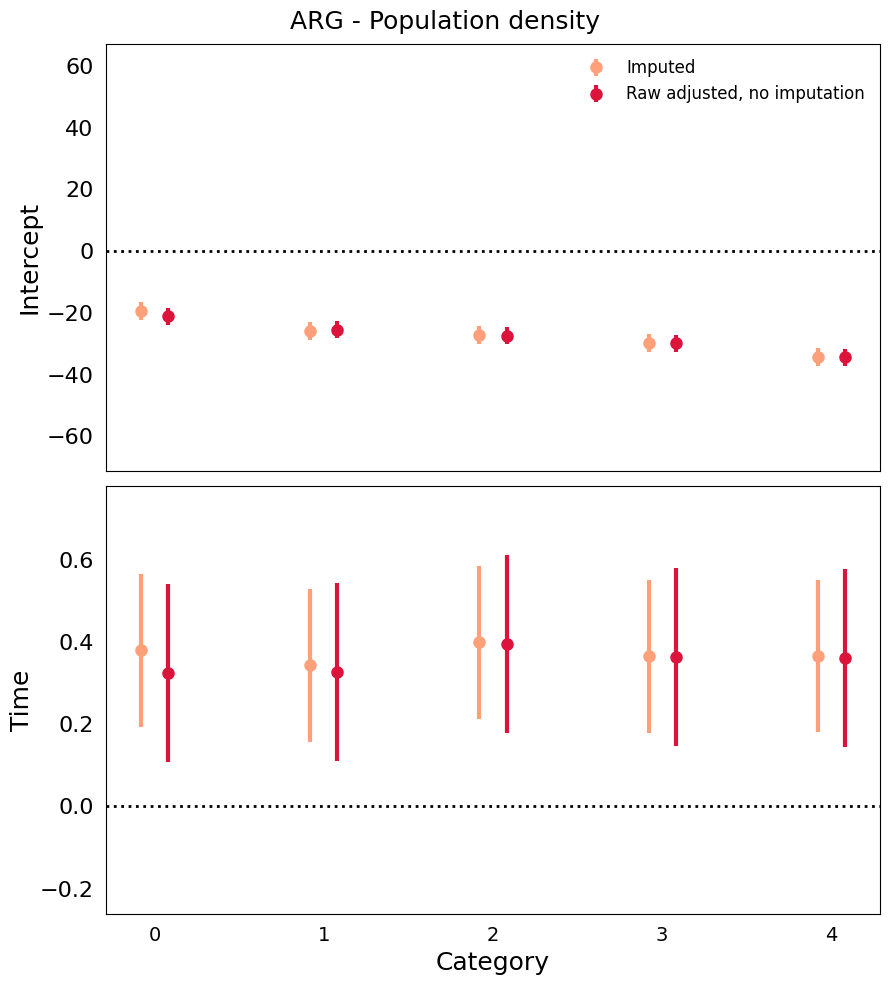

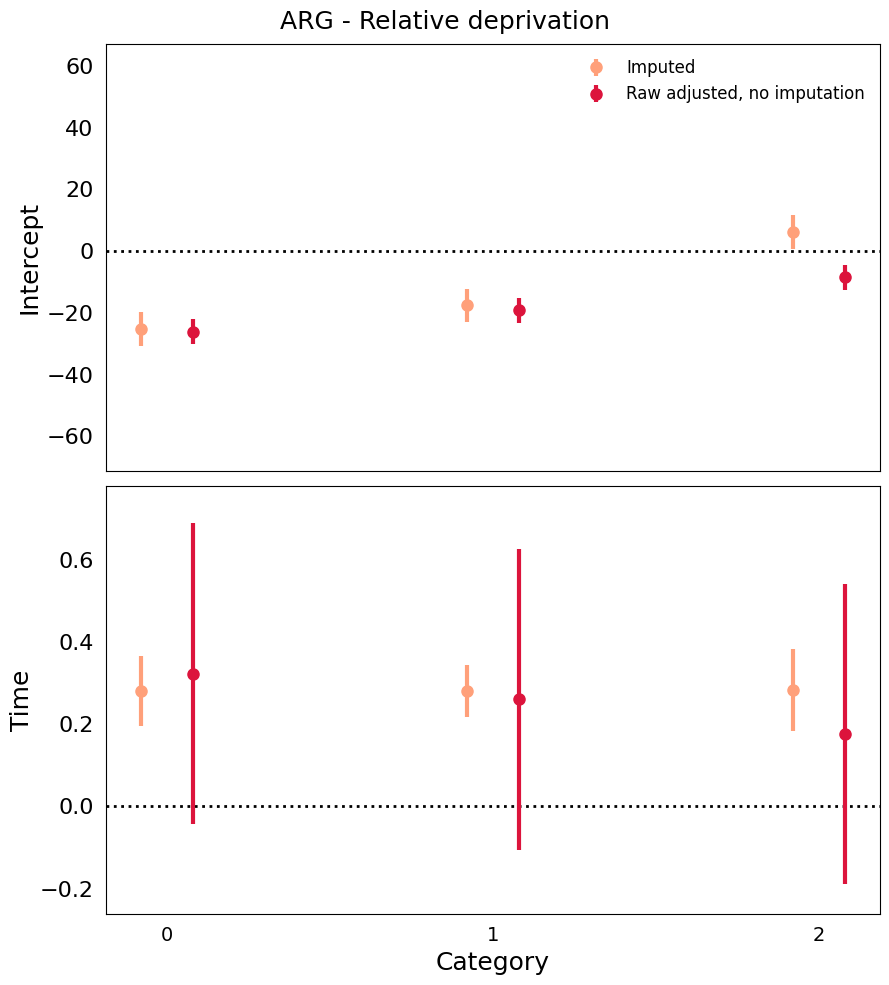

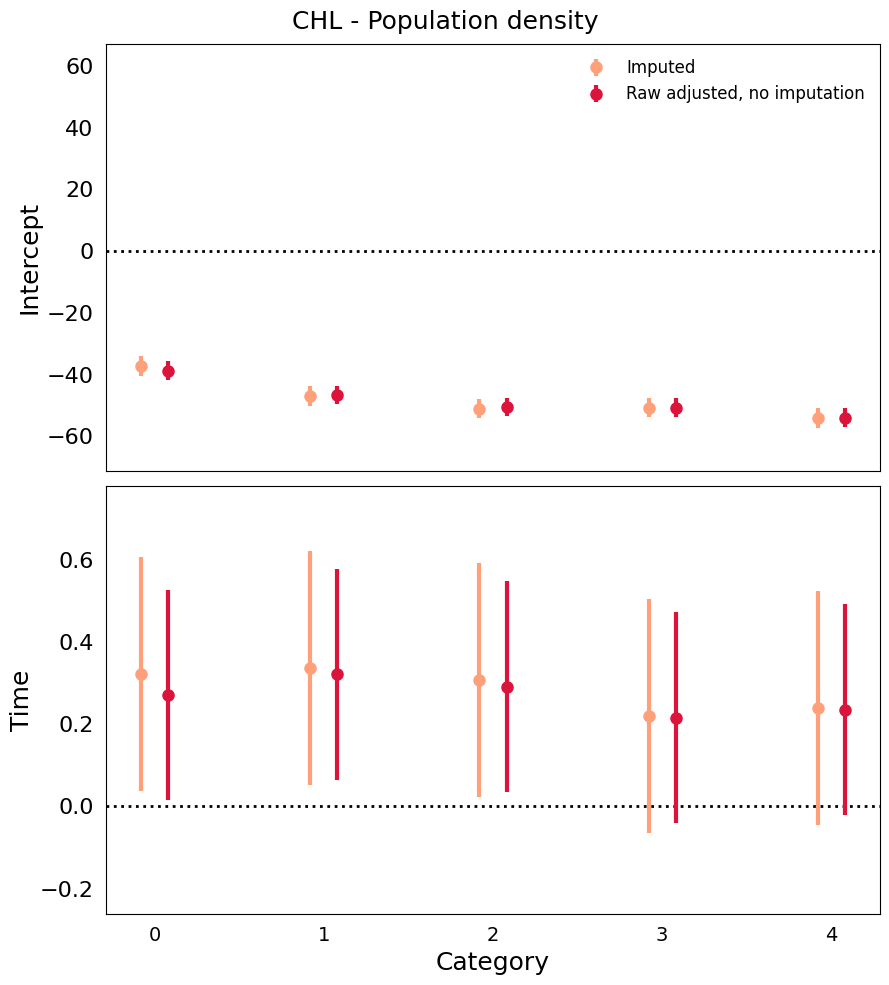

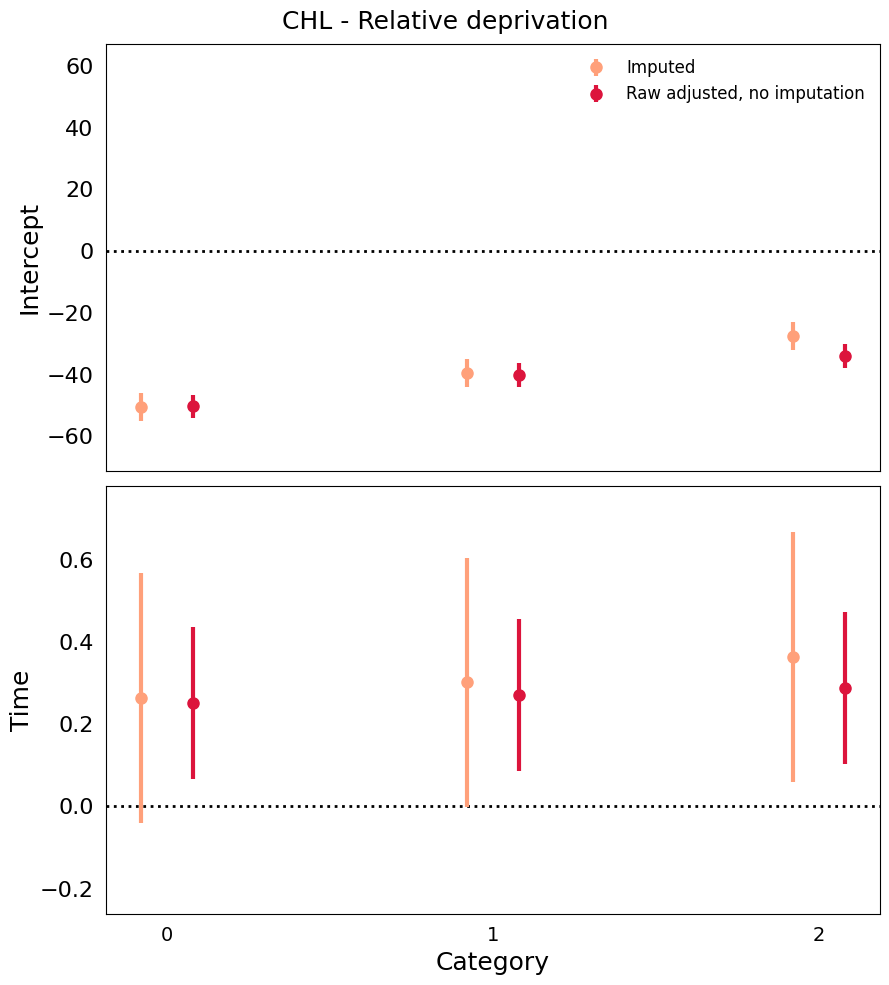

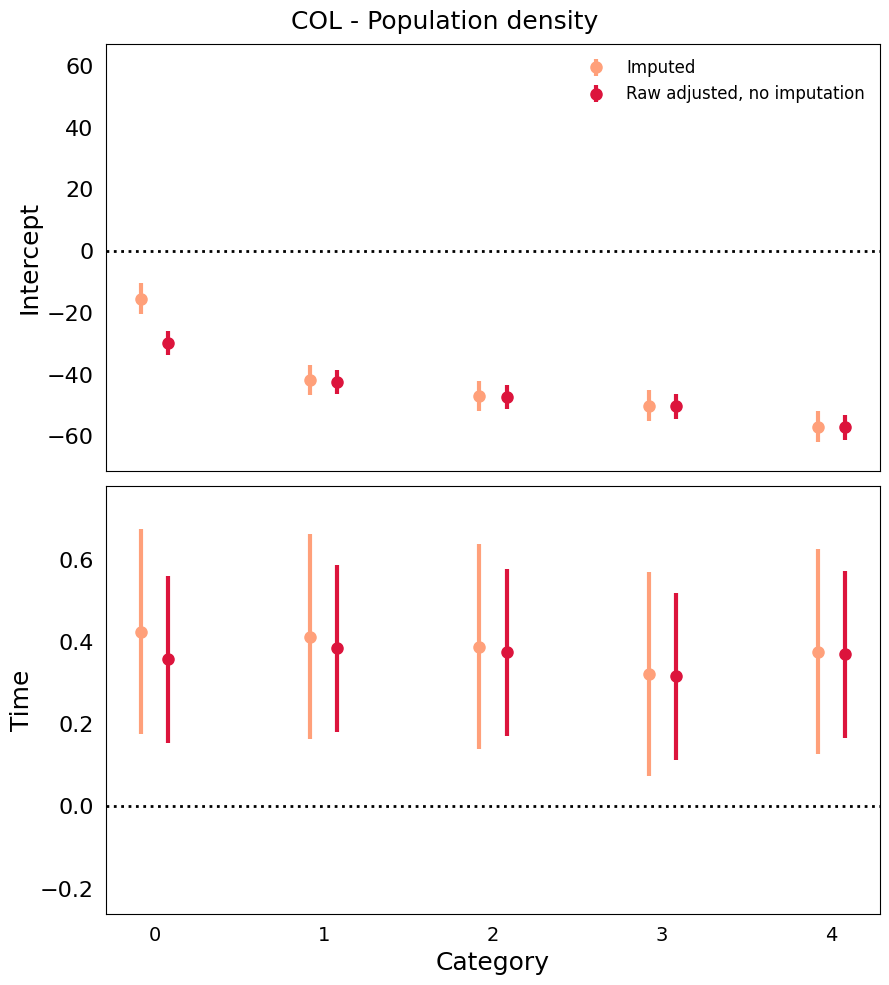

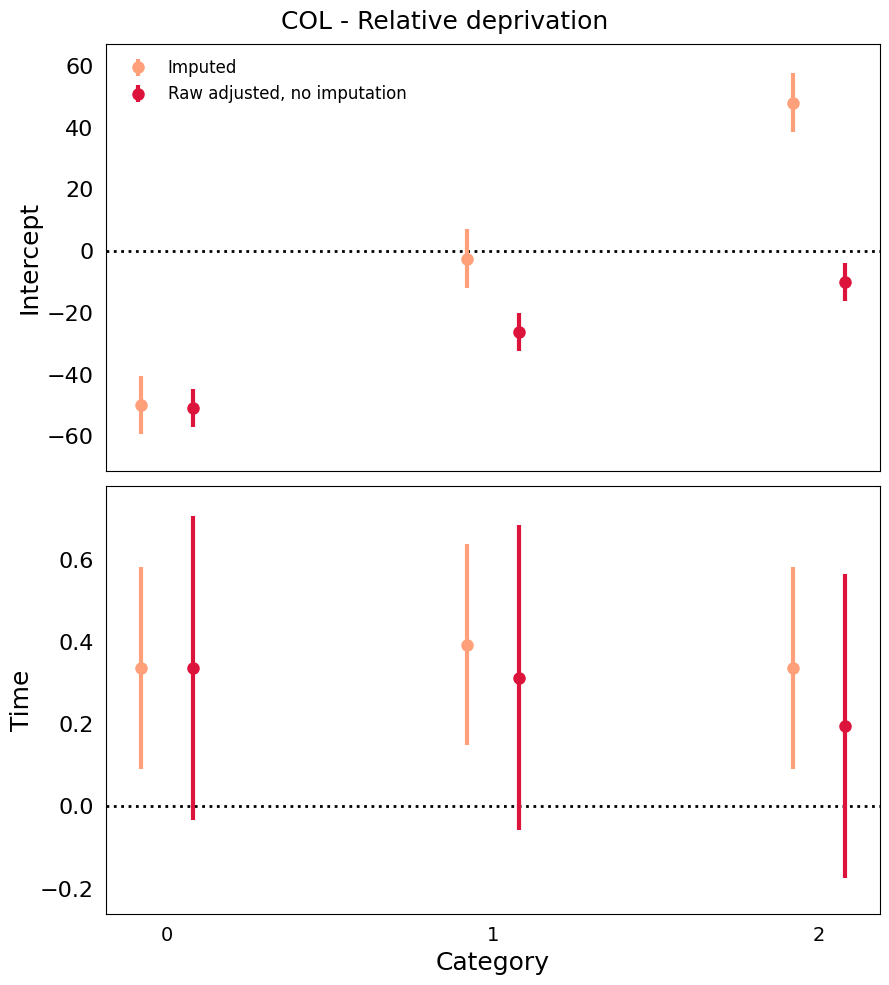

['/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/model6-sensitivity-r2/ARG_density_model6_imputed_vs_raw_r2.pdf',
 '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/model6-sensitivity-r2/ARG_rdi_model6_imputed_vs_raw_r2.pdf',
 '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/model6-sensitivity-r2/CHL_density_model6_imputed_vs_raw_r2.pdf',
 '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/model6-sensitivity-r2/CHL_rdi_model6_imputed_vs_raw_r2.pdf',
 '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/model6-sensitivity-r2/COL_density_model6_imputed_vs_raw_r2.pdf',
 '/Users/carmen/Library/CloudStorage/OneDrive-TheUniversityofLiverpool/research/latin-mobility-covid/plots/model6-sensitivity-r2/COL_rdi_model6_impu

In [14]:
plot_dir = os.path.join(wd, 'plots', 'model6-sensitivity-r2')
os.makedirs(plot_dir, exist_ok=True)

intercept_ylim = get_axis_limits(df_long, 'intercept_estimate', 'intercept_conf_low', 'intercept_conf_high')
time_ylim = get_axis_limits(df_long, 'time_estimate', 'time_conf_low', 'time_conf_high')

plot_paths = []
for country_short in countries.values():
    for grouping in groupings:
        plot_paths.append(
            plot_model6_comparison(
                df_long,
                country_short,
                grouping,
                plot_dir,
                intercept_ylim=intercept_ylim,
                time_ylim=time_ylim,
            )
        )

plot_paths


# Save outputs

In [ ]:
output_dir = os.path.join(wd, 'data', 'outputs', 'supplementary-tables')
os.makedirs(output_dir, exist_ok=True)

comparison_tag = f'{imputed_version}-vs-raw-adjusted'
long_path = os.path.join(output_dir, f'model6-sensitivity-{comparison_tag}-long-r2.csv')
wide_path = os.path.join(output_dir, f'model6-sensitivity-{comparison_tag}-table-r2.csv')

df_long.to_csv(long_path, index=False)
df_wide.to_csv(wide_path, index=False)

print(long_path)
print(wide_path)
